In [ ]:
from google.colab import drive #Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd #pandas moduls import
import csv #csv moduls import
import numpy as np
import seaborn as sns

In [ ]:
NBA = pd.read_csv("/content/drive/MyDrive/IntBigData/nba_league_leaders.csv")

In [ ]:
NBA.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,EFF
0,1629029,1,Luka Dončić,1610612742,DAL,70,37.5,11.5,23.6,0.487,...,0.786,0.8,8.4,9.2,9.8,1.4,0.5,4.0,33.9,36.9
1,203507,2,Giannis Antetokounmpo,1610612749,MIL,73,35.2,11.5,18.8,0.611,...,0.657,2.7,8.8,11.5,6.5,1.2,1.1,3.4,30.4,36.4
2,1628983,3,Shai Gilgeous-Alexander,1610612760,OKC,75,34.0,10.6,19.8,0.535,...,0.874,0.9,4.7,5.5,6.2,2.0,0.9,2.2,30.1,32.2
3,1628973,4,Jalen Brunson,1610612752,NYK,77,35.4,10.3,21.4,0.479,...,0.847,0.6,3.1,3.6,6.7,0.9,0.2,2.4,28.7,25.6
4,201142,5,Kevin Durant,1610612756,PHX,75,37.2,10.0,19.1,0.523,...,0.856,0.5,6.1,6.6,5.0,0.9,1.2,3.3,27.1,27.7


In [ ]:
NBA.columns

Index(['PLAYER_ID', 'RANK', 'PLAYER', 'TEAM_ID', 'TEAM', 'GP', 'MIN', 'FGM',
       'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT',
       'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PTS', 'EFF'],
      dtype='object')

In [ ]:
NBA['Offensive_Rating'] = (#공격지표는 말 그대로 점수를 벌어다 줄 수 있는 공격력을 의미함
    (NBA['PTS'] * 1.5) + #득점은 점수를 버는 가장 직관적인 지표이므로 가장 높은 가중치를 가짐
    (NBA['AST'] * 1.2) + #어시스트는 득점 다음으로 점수를 버는 직관적인 지표이므로 다음 가는 가중치를 가짐
    (NBA['FG_PCT'] * 50) + #필드골과 3점슛, 자유투는 점수와는 관계없이 가장 직관적인 공격 기회로 보며 동일한 가중치를 제공함
    (NBA['FG3_PCT'] * 50) +
    (NBA['FTA'] * 50) +
    (NBA['OREB'] * 1.1) + #공격 리바운드는 상대 필드 진영에서 우리가 다시한번 공격할 수 있는 기회를 의미하므로 1.1의 가중치를 가짐
    (NBA['STL'] * 1.3) - #스틸은 적의 공격을 저지함과 동시에 곧바로 속공으로 연계될 수 있으므로 1.3의 높은 가중치를 가짐
    (NBA['TOV'] * 1.5)#실책은 반대로 팀의 공격을 잃음과 동시에 적에게 공격기회를 제공하므로 1.5의 높은 가중치를 가
) / NBA['GP']
print(NBA[['PLAYER', 'Offensive_Rating']])

                      PLAYER  Offensive_Rating
0                Luka Dončić          7.682286
1      Giannis Antetokounmpo          8.658630
2    Shai Gilgeous-Alexander          7.097067
3              Jalen Brunson          5.432727
4               Kevin Durant          4.936267
..                       ...               ...
235                KJ Martin          1.387833
236            Dwight Powell          2.040159
237               Zeke Nnaji          1.682241
238                  JT Thor          0.956825
239              Dalen Terry          1.275085

[240 rows x 2 columns]


In [ ]:
NBA.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,OREB,DREB,REB,AST,STL,BLK,TOV,PTS,EFF,Offensive_Rating
0,1629029,1,Luka Dončić,1610612742,DAL,70,37.5,11.5,23.6,0.487,...,0.8,8.4,9.2,9.8,1.4,0.5,4.0,33.9,36.9,7.682286
1,203507,2,Giannis Antetokounmpo,1610612749,MIL,73,35.2,11.5,18.8,0.611,...,2.7,8.8,11.5,6.5,1.2,1.1,3.4,30.4,36.4,8.658630
2,1628983,3,Shai Gilgeous-Alexander,1610612760,OKC,75,34.0,10.6,19.8,0.535,...,0.9,4.7,5.5,6.2,2.0,0.9,2.2,30.1,32.2,7.097067
3,1628973,4,Jalen Brunson,1610612752,NYK,77,35.4,10.3,21.4,0.479,...,0.6,3.1,3.6,6.7,0.9,0.2,2.4,28.7,25.6,5.432727
4,201142,5,Kevin Durant,1610612756,PHX,75,37.2,10.0,19.1,0.523,...,0.5,6.1,6.6,5.0,0.9,1.2,3.3,27.1,27.7,4.936267


In [ ]:
NBA['Defensive_Rating'] = (
    (NBA['DREB'] * 2.0) +
    (NBA['BLK'] * 1.8) +
    (NBA['STL'] * 1.5) +
    (NBA['OREB'] * 1.0) -
    (NBA['TOV'] * 1.5)
) / NBA['GP']

In [ ]:
print(NBA[['PLAYER', 'Offensive_Rating','Defensive_Rating']])

                      PLAYER  Offensive_Rating  Defensive_Rating
0                Luka Dončić          7.682286          0.208571
1      Giannis Antetokounmpo          8.658630          0.260000
2    Shai Gilgeous-Alexander          7.097067          0.154933
3              Jalen Brunson          5.432727          0.063766
4               Kevin Durant          4.936267          0.150133
..                       ...               ...               ...
235                KJ Martin          1.387833          0.065167
236            Dwight Powell          2.040159          0.090317
237               Zeke Nnaji          1.682241          0.073448
238                  JT Thor          0.956825          0.073333
239              Dalen Terry          1.275085          0.065085

[240 rows x 3 columns]


In [ ]:
# Offensive Rating과 Defensive Rating의 최솟값과 최댓값 구하기
offensive_min = NBA['Offensive_Rating'].min()
offensive_max = NBA['Offensive_Rating'].max()

defensive_min = NBA['Defensive_Rating'].min()
defensive_max = NBA['Defensive_Rating'].max()

# Offensive Rating과 Defensive Rating을 10점 만점 기준으로 정규화
NBA['Scaled_Offensive_Rating'] = ((NBA['Offensive_Rating'] - offensive_min) / (offensive_max - offensive_min)) * 10
NBA['Scaled_Defensive_Rating'] = ((NBA['Defensive_Rating'] - defensive_min) / (defensive_max - defensive_min)) * 10

# 결과 출력
print(NBA[['PLAYER', 'Scaled_Offensive_Rating', 'Scaled_Defensive_Rating']])

                      PLAYER  Scaled_Offensive_Rating  Scaled_Defensive_Rating
0                Luka Dončić                 8.775085                 6.177978
1      Giannis Antetokounmpo                10.000000                 7.830745
2    Shai Gilgeous-Alexander                 8.040874                 4.454205
3              Jalen Brunson                 5.952805                 1.524357
4               Kevin Durant                 5.329949                 4.299946
..                       ...                      ...                      ...
235                KJ Martin                 0.878110                 1.569363
236            Dwight Powell                 1.696513                 2.377637
237               Zeke Nnaji                 1.247473                 1.835510
238                  JT Thor                 0.337371                 1.831816
239              Dalen Terry                 0.736657                 1.566730

[240 rows x 3 columns]


In [ ]:
selected_players = ["Jayson Tatum", "Luka Dončić","Jarrett Allen","Nikola Jokić","Tyrese Haliburton","Anthony Edwards","Jalen Brunson","Shai Gilgeous-Alexander","James Harden","LeBron James","Giannis Antetokounmpo","Stephen Curry","Kevin Durant"]

# 조건에 맞는 선수들로 새로운 데이터프레임 생성
filtered_df = NBA[NBA["PLAYER"].isin(selected_players)]

# 결과 출력
print(filtered_df)

    PLAYER_ID  RANK                   PLAYER     TEAM_ID TEAM  GP   MIN   FGM  \
0     1629029     1              Luka Dončić  1610612742  DAL  70  37.5  11.5   
1      203507     2    Giannis Antetokounmpo  1610612749  MIL  73  35.2  11.5   
2     1628983     3  Shai Gilgeous-Alexander  1610612760  OKC  75  34.0  10.6   
3     1628973     4            Jalen Brunson  1610612752  NYK  77  35.4  10.3   
4      201142     5             Kevin Durant  1610612756  PHX  75  37.2  10.0   
6     1628369     7             Jayson Tatum  1610612738  BOS  74  35.7   9.1   
8      201939     9            Stephen Curry  1610612744  GSW  74  32.7   8.8   
9      203999    10             Nikola Jokić  1610612743  DEN  79  34.6  10.4   
11    1630162    12          Anthony Edwards  1610612750  MIN  79  35.1   9.1   
12       2544    13             LeBron James  1610612747  LAL  71  35.3   9.6   
36    1630169    37        Tyrese Haliburton  1610612754  IND  69  32.2   7.2   
60     201935    61         

In [ ]:
# CSV로 저장
filtered_df.to_csv("selected_players.csv", index=False)


In [ ]:
# 남기고 싶은 팀 목록
selected_teams = [
    "BOS",  # 보스턴
    "CLE",  # 클리블랜드
    "IND",  # 인디애나
    "NYK",  # 뉴욕
    "OKC",  # 오클라호마시티
    "DAL",  # 댈러스
    "MIN",  # 미네소타
    "DEN"   # 덴버
]

# 선택한 팀들만 남기기
filtered_df = NBA[NBA['TEAM'].isin(selected_teams)]

# 결과 출력
print(filtered_df)

     PLAYER_ID  RANK                   PLAYER     TEAM_ID TEAM  GP   MIN  \
0      1629029     1              Luka Dončić  1610612742  DAL  70  37.5   
2      1628983     3  Shai Gilgeous-Alexander  1610612760  OKC  75  34.0   
3      1628973     4            Jalen Brunson  1610612752  NYK  77  35.4   
6      1628369     7             Jayson Tatum  1610612738  BOS  74  35.7   
9       203999    10             Nikola Jokić  1610612743  DEN  79  34.6   
..         ...   ...                      ...         ...  ...  ..   ...   
221    1629026   222         Kenrich Williams  1610612760  OKC  69  14.9   
232     203200   233           Justin Holiday  1610612743  DEN  58  14.9   
233    1631119   234          Jaylin Williams  1610612760  OKC  69  13.0   
236     203939   237            Dwight Powell  1610612742  DAL  63  13.3   
237    1630192   238               Zeke Nnaji  1610612743  DEN  58   9.9   

      FGM   FGA  FG_PCT  ...  AST  STL  BLK  TOV   PTS   EFF  \
0    11.5  23.6   0.487

In [ ]:
filtered_df.to_csv("filtered_teams.csv", index=False, encoding='utf-8-sig')

# 팀별 비교

In [ ]:
NBA = pd.read_csv("/content/drive/MyDrive/IntBigData/filtered_teams.csv")

In [ ]:
NBA.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,AST,STL,BLK,TOV,PTS,EFF,Offensive_Rating,Defensive_Rating,Scaled_Offensive_Rating,Scaled_Defensive_Rating
0,1629029,1,Luka Dončić,1610612742,DAL,70,37.5,11.5,23.6,0.487,...,9.8,1.4,0.5,4.0,33.9,36.9,7.682286,0.208571,8.775085,6.177978
1,1628983,3,Shai Gilgeous-Alexander,1610612760,OKC,75,34.0,10.6,19.8,0.535,...,6.2,2.0,0.9,2.2,30.1,32.2,7.097067,0.154933,8.040874,4.454205
2,1628973,4,Jalen Brunson,1610612752,NYK,77,35.4,10.3,21.4,0.479,...,6.7,0.9,0.2,2.4,28.7,25.6,5.432727,0.063766,5.952805,1.524357
3,1628369,7,Jayson Tatum,1610612738,BOS,74,35.7,9.1,19.3,0.471,...,4.9,1.0,0.6,2.5,26.9,27.6,5.704324,0.190946,6.293549,5.611546
4,203999,10,Nikola Jokić,1610612743,DEN,79,34.6,10.4,17.9,0.583,...,9.0,1.4,0.9,3.0,26.4,38.5,4.720253,0.266076,5.058940,8.026008


In [ ]:
pip install nba_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 279.4/279.4 kB 6.3 MB/s eta 0:00:00


In [ ]:
from nba_api.stats.endpoints import commonplayerinfo

# Luka Dončić의 ID
player_id = 1629029  # find_players_by_full_name로 얻은 ID

# 선수 정보 가져오기
player_info = commonplayerinfo.CommonPlayerInfo(player_id=player_id)
player_data = player_info.get_normalized_dict()

# 포지션 출력
position = player_data['CommonPlayerInfo'][0]['POSITION']
print(f"Luka Dončić의 포지션: {position}")

Luka Dončić의 포지션: Forward-Guard


In [ ]:
from nba_api.stats.endpoints import commonplayerinfo
import pandas as pd
import time



# 포지션 데이터를 저장할 리스트
positions = []

# 각 선수의 포지션 가져오기
for player_id in NBA["PLAYER_ID"]:
    try:
        # API 호출로 포지션 가져오기
        player_info = commonplayerinfo.CommonPlayerInfo(player_id=player_id)
        player_data = player_info.get_normalized_dict()
        position = player_data['CommonPlayerInfo'][0]['POSITION']
    except Exception as e:
        position = "Unknown"  # 오류 발생 시 기본값 설정
        print(f"Error fetching position for player {player_id}: {e}")

    # 포지션 리스트에 추가
    positions.append(position)


# 데이터프레임에 Position 열 추가
NBA["Position"] = positions

# 결과 출력
print(NBA)

Error fetching position for player 1629638: HTTPSConnectionPool(host='stats.nba.com', port=443): Read timed out. (read timeout=30)
    PLAYER_ID  RANK                   PLAYER     TEAM_ID TEAM  GP   MIN   FGM  \
0     1629029     1              Luka Dončić  1610612742  DAL  70  37.5  11.5   
1     1628983     3  Shai Gilgeous-Alexander  1610612760  OKC  75  34.0  10.6   
2     1628973     4            Jalen Brunson  1610612752  NYK  77  35.4  10.3   
3     1628369     7             Jayson Tatum  1610612738  BOS  74  35.7   9.1   
4      203999    10             Nikola Jokić  1610612743  DEN  79  34.6  10.4   
..        ...   ...                      ...         ...  ...  ..   ...   ...   
63    1629026   222         Kenrich Williams  1610612760  OKC  69  14.9   1.9   
64     203200   233           Justin Holiday  1610612743  DEN  58  14.9   1.5   
65    1631119   234          Jaylin Williams  1610612760  OKC  69  13.0   1.4   
66     203939   237            Dwight Powell  1610612742  D

In [ ]:
# PLAYER_ID를 기반으로 Position 업데이트
for player_id in NBA["PLAYER_ID"]:
    try:
        # API 호출
        player_info = commonplayerinfo.CommonPlayerInfo(player_id=player_id, timeout=60)
        player_data = player_info.get_normalized_dict()
        position = player_data['CommonPlayerInfo'][0]['POSITION']

        # 데이터프레임에 직접 업데이트
        NBA.loc[NBA["PLAYER_ID"] == player_id, "Position"] = position
    except Exception as e:
        print(f"Error fetching position for player {player_id}: {e}")
    time.sleep(1)  # API 호출 제한 방지를 위해 1초 대기

# 결과 출력
print(NBA)

    PLAYER_ID  RANK                   PLAYER     TEAM_ID TEAM  GP   MIN   FGM  \
0     1629029     1              Luka Dončić  1610612742  DAL  70  37.5  11.5   
1     1628983     3  Shai Gilgeous-Alexander  1610612760  OKC  75  34.0  10.6   
2     1628973     4            Jalen Brunson  1610612752  NYK  77  35.4  10.3   
3     1628369     7             Jayson Tatum  1610612738  BOS  74  35.7   9.1   
4      203999    10             Nikola Jokić  1610612743  DEN  79  34.6  10.4   
..        ...   ...                      ...         ...  ...  ..   ...   ...   
63    1629026   222         Kenrich Williams  1610612760  OKC  69  14.9   1.9   
64     203200   233           Justin Holiday  1610612743  DEN  58  14.9   1.5   
65    1631119   234          Jaylin Williams  1610612760  OKC  69  13.0   1.4   
66     203939   237            Dwight Powell  1610612742  DAL  63  13.3   1.1   
67    1630192   238               Zeke Nnaji  1610612743  DEN  58   9.9   1.2   

     FGA  FG_PCT  ...  STL 

In [ ]:
NBA.to_csv("filtered_teamsfin.csv", index=False, encoding='utf-8-sig')

NameError: name 'NBA' is not defined

In [ ]:
NBA.head()

,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,...,STL,BLK,TOV,PTS,EFF,Offensive_Rating,Defensive_Rating,Scaled_Offensive_Rating,Scaled_Defensive_Rating,Position
0,1629029,1,Luka Dončić,1610612742,DAL,70,37.5,11.5,23.6,0.487,...,1.4,0.5,4.0,33.9,36.9,7.682286,0.208571,8.775085,6.177978,Forward-Guard
1,1628983,3,Shai Gilgeous-Alexander,1610612760,OKC,75,34.0,10.6,19.8,0.535,...,2.0,0.9,2.2,30.1,32.2,7.097067,0.154933,8.040874,4.454205,Guard
2,1628973,4,Jalen Brunson,1610612752,NYK,77,35.4,10.3,21.4,0.479,...,0.9,0.2,2.4,28.7,25.6,5.432727,0.063766,5.952805,1.524357,Guard
3,1628369,7,Jayson Tatum,1610612738,BOS,74,35.7,9.1,19.3,0.471,...,1.0,0.6,2.5,26.9,27.6,5.704324,0.190946,6.293549,5.611546,Forward-Guard
4,203999,10,Nikola Jokić,1610612743,DEN,79,34.6,10.4,17.9,0.583,...,1.4,0.9,3.0,26.4,38.5,4.720253,0.266076,5.058940,8.026008,Center


In [ ]:
# 팀별 집계
team_stats = NBA.groupby("TEAM").agg({
    "PTS": "sum",  # 팀 총 득점
    "FGM": "sum",  # 총 필드골 성공
    "FGA": "sum",  # 총 필드골 시도
    "AST": "sum",  # 총 어시스트
    "STL": "sum",  # 총 스틸
    "BLK": "sum",  # 총 블록
    "Offensive_Rating": "mean",  # 공격 효율성 평균
    "Defensive_Rating": "mean",  # 수비 효율성 평균
    "MIN": "sum",  # 총 플레이 시간
}).reset_index()

# 필드골 성공률 추가 계산
team_stats["FG_PCT"] = (team_stats["FGM"] / team_stats["FGA"]) * 100

In [ ]:
# 팀별 득점 기여도
NBA["PTS_Contribution"] = NBA["PTS"] / NBA.groupby("TEAM")["PTS"].transform("sum")

# 팀별 어시스트 기여도
NBA["AST_Contribution"] = NBA["AST"] / NBA.groupby("TEAM")["AST"].transform("sum")
9
# 팀별 시간 기여도
NBA["MIN_Contribution"] = NBA["MIN"] / NBA.groupby("TEAM")["MIN"].transform("sum")

In [ ]:
NBA["Possessions"] = (
    NBA["FGA"] + 0.44 * NBA["FTA"] - NBA["Offensive_Rating"] + NBA["TOV"]
)

# 팀별 포제션 집계
team_possessions = NBA.groupby("TEAM")["Possessions"].sum().reset_index()

In [ ]:
# 팀별 총 플레이 시간
team_minutes = NBA.groupby("TEAM")["MIN"].sum().reset_index()

# Pace 계산
team_pace = team_possessions.merge(team_minutes, on="TEAM")
team_pace["Pace"] = 48 * (team_pace["Possessions"] / team_pace["MIN"])

In [ ]:
# 팀별 최고의 득점 효율성을 가진 선수
top_offensive_players = NBA.loc[NBA.groupby("TEAM")["Offensive_Rating"].idxmax()][
    ["TEAM", "PLAYER", "Offensive_Rating", "PTS"]
]

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54016 (\N{HANGUL SYLLABLE TIM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46301 (\N{HANGUL SYLLABLE DEUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages

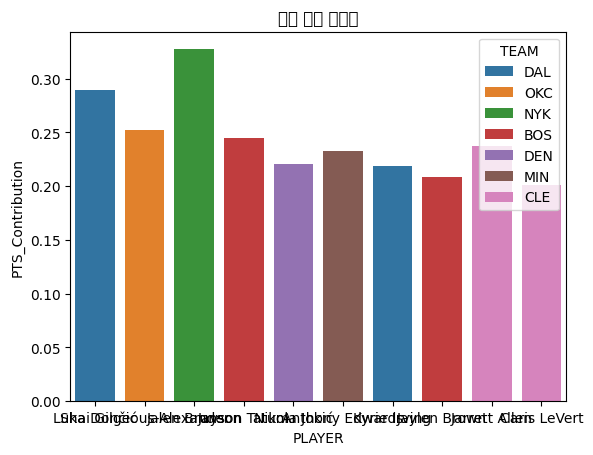

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 득점 비중 상위 5명
top_scorers = NBA[NBA["PTS_Contribution"] > 0.2]  # 득점 비중 20% 이상 선수
sns.barplot(data=top_scorers, x="PLAYER", y="PTS_Contribution", hue="TEAM")
plt.title("팀별 주요 득점원")
plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54016 (\N{HANGUL SYLLABLE TIM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53596 (\N{HANGUL SYLLABLE TEM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


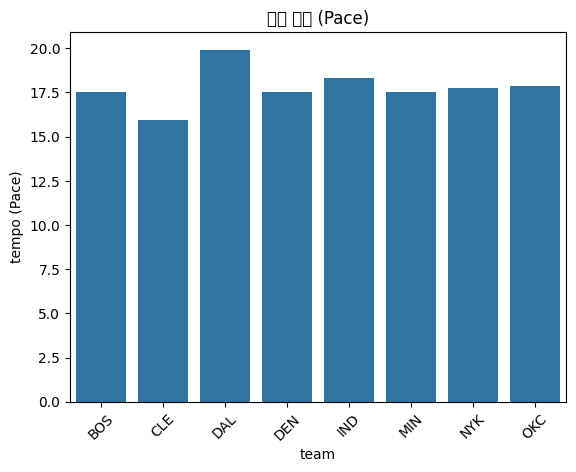

In [ ]:
sns.barplot(data=team_pace, x="TEAM", y="Pace")
plt.title("팀별 템포 (Pace)")
plt.xlabel("team")
plt.ylabel("tempo (Pace)")
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50984 (\N{HANGUL SYLLABLE YUL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54016 (\N{HANGUL SYLLABLE TIM}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IP

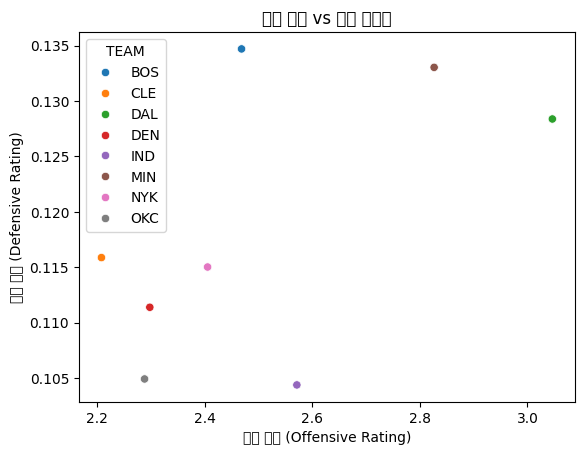

In [ ]:
sns.scatterplot(data=team_stats, x="Offensive_Rating", y="Defensive_Rating", hue="TEAM")
plt.title("팀별 공격 vs 수비 효율성")
plt.xlabel("공격 효율 (Offensive Rating)")
plt.ylabel("수비 효율 (Defensive Rating)")
plt.show()

In [ ]:
# 각 팀의 선수 리스트 출력
teams_players = NBA.groupby("TEAM")["PLAYER"].apply(list)

# 결과 출력
print(teams_players)


TEAM
BOS    [Jayson Tatum, Jaylen Brown, Derrick White, Jr...
CLE    [Jarrett Allen, Caris LeVert, Max Strus, Isaac...
DAL    [Luka Dončić, Kyrie Irving, Tim Hardaway Jr., ...
DEN    [Nikola Jokić, Jamal Murray, Michael Porter Jr...
IND    [Pascal Siakam, Tyrese Haliburton, Myles Turne...
MIN    [Anthony Edwards, Karl-Anthony Towns, Rudy Gob...
NYK    [Jalen Brunson, Donte DiVincenzo, Alec Burks, ...
OKC    [Shai Gilgeous-Alexander, Jalen Williams, Chet...
Name: PLAYER, dtype: object


In [ ]:
lakers_players = teams_players["OKC"]
print(lakers_players)

['Shai Gilgeous-Alexander', 'Jalen Williams', 'Chet Holmgren', 'Josh Giddey', 'Luguentz Dort', 'Isaiah Joe', 'Aaron Wiggins', 'Cason Wallace', 'Kenrich Williams', 'Jaylin Williams']


In [ ]:
NBA = pd.read_csv("/content/drive/MyDrive/IntBigData/selected_players.csv")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
# 시각화에 사용할 주요 지표
categories = ["PTS", "REB", "AST","Offensive_Rating", "Defensive_Rating"]
num_vars = len(categories)

# 데이터 정규화 (0~1 범위로)
df_normalized = NBA.copy()
for col in categories:
    df_normalized[col] = (NBA[col] - NBA[col].min()) / (NBA[col].max() - NBA[col].min())

# 레이더 차트를 그리기 위한 함수 (한 명의 선수)
def plot_radar(player_data, player_name, team_name, categories):
    # 각 축에 대한 각도 계산
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # 폐곡선을 위해 마지막 점 추가

    # 폴라 차트 생성
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # 데이터 준비
    values = player_data.tolist()
    values += values[:1]  # 폐곡선을 위해 마지막 점 추가

    # 레이더 차트 그리기
    ax.fill(angles, values, color='blue', alpha=0.25)
    ax.plot(angles, values, color='blue', linewidth=2)
    ax.set_yticks([])  # y축 라벨 제거
    ax.set_xticks(angles[:-1])  # x축 라벨
    ax.set_xticklabels(categories, fontsize=12)
    ax.set_title(f"{player_name} ({team_name})", fontsize=14, pad=20)
    plt.show()


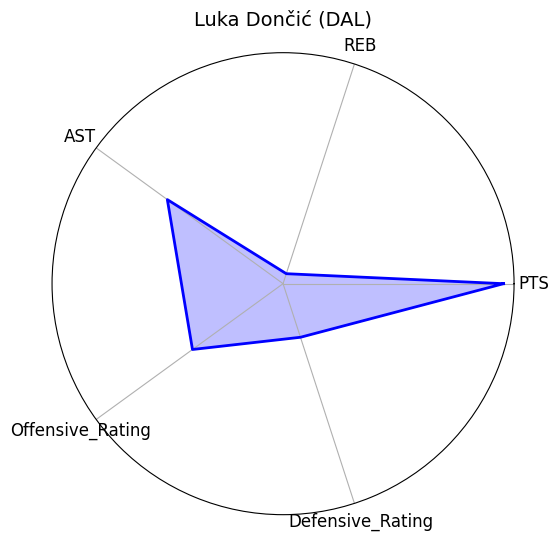

In [ ]:

# 예시로 Luka Dončić의 레이더 차트 생성
luka_data = df_normalized[df_normalized["PLAYER"] == "Luka Dončić"][categories].iloc[0]
plot_radar(luka_data, "Luka Dončić", "DAL", categories)

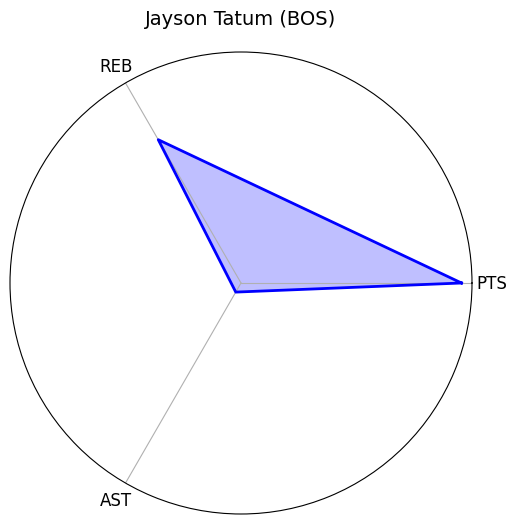

In [ ]:
Jayson_data = df_normalized[df_normalized["PLAYER"] == "Jayson Tatum"][categories].iloc[0]
plot_radar(Jayson_data, "Jayson Tatum", "BOS", categories)

In [ ]:
def plot_radar_comparison(player1_data, player2_data, player1_name, player2_name, categories):
    # 각 축에 대한 각도 계산
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # 폐곡선을 위해 마지막 점 추가

    # 폴라 차트 생성
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # 선수 1 데이터 준비
    values1 = player1_data.tolist()
    values1 += values1[:1]  # 폐곡선을 위해 마지막 점 추가

    # 선수 2 데이터 준비
    values2 = player2_data.tolist()
    values2 += values2[:1]  # 폐곡선을 위해 마지막 점 추가

    # 선수 1 레이더 차트
    ax.fill(angles, values1, color='blue', alpha=0.25, label=player1_name)
    ax.plot(angles, values1, color='blue', linewidth=2)

    # 선수 2 레이더 차트
    ax.fill(angles, values2, color='red', alpha=0.25, label=player2_name)
    ax.plot(angles, values2, color='red', linewidth=2)

    # 설정
    ax.set_yticks([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=10)
    ax.set_title("Player Comparison", fontsize=16, pad=20)
    plt.show()

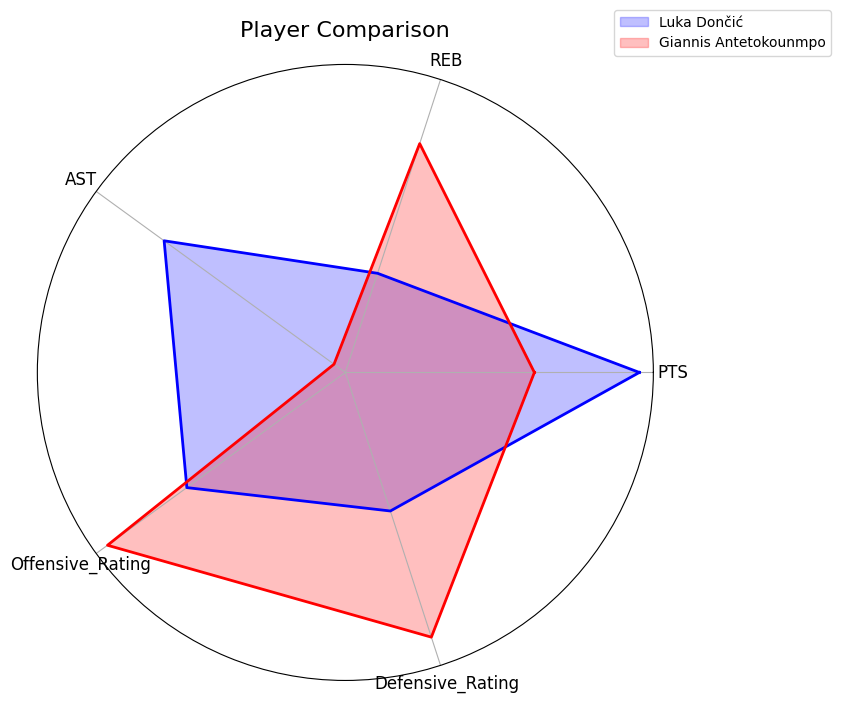

In [ ]:
# 두 선수 데이터 선택
player1_data = df_normalized[df_normalized["PLAYER"] == "Luka Dončić"][categories].iloc[0]
player2_data = df_normalized[df_normalized["PLAYER"] == "Giannis Antetokounmpo"][categories].iloc[0]

# 비교 레이더 차트 생성
plot_radar_comparison(player1_data, player2_data, "Luka Dončić", "Giannis Antetokounmpo", categories)

In [ ]:
# 각 팀별 Offensive_Rating 및 Defensive_Rating 합계 계산
team_rating_sums = NBA.groupby("TEAM")[["Scaled_Offensive_Rating", "Scaled_Defensive_Rating"]].mean()


# 결과 출력
print(team_rating_sums)

      Scaled_Offensive_Rating  Scaled_Defensive_Rating
TEAM                                                  
BOS                  2.233677                 3.803756
CLE                  1.906890                 3.199094
DAL                  2.958727                 3.600711
DEN                  2.019703                 3.055089
IND                  2.362733                 2.830069
MIN                  2.682918                 3.750320
NYK                  2.154477                 3.171766
OKC                  2.007453                 2.847314
